# Phase 3 — Monte Carlo Tournament Simulation

Use the Elo model from Phase 1 to simulate the 2026 World Cup **ten thousand times**
and produce probabilities for every team: chance of advancing from the group,
reaching each knockout round, and lifting the trophy.

Two layers of simulation:

1. **Group stage** — 12 groups, 4 teams each, top 2 + best 8 third-placers advance
2. **Knockout bracket** — 32-team bracket following FIFA's official Round of 32
   pairings and the 495-combination Annex C third-place placement table

Each match is a single random draw weighted by the Elo win probability. Aggregating
across 10,000 simulated tournaments turns randomness into useful probabilities.

---

Verwendung des Elo-Modells aus Phase 1, um die WM 2026 **zehntausendmal** zu
simulieren und Wahrscheinlichkeiten für jede Mannschaft zu erzeugen: Chance auf
das Weiterkommen aus der Gruppe, das Erreichen jeder K.O.-Runde und den
Titelgewinn.

Zwei Simulationsebenen:

1. **Gruppenphase** — 12 Gruppen mit je 4 Mannschaften, die Top 2 + die 8 besten
   Gruppendritten kommen weiter
2. **K.O.-Bracket** — 32er-Bracket nach FIFAs offiziellen Round-of-32-Paarungen
   und der 495-Kombinationen-Tabelle aus Anhang C der Turnierregeln

Jedes Spiel ist ein einzelner Zufallszug, gewichtet nach der Elo-Siegwahrscheinlichkeit.
Die Aggregation über 10.000 simulierte Turniere verwandelt Zufall in nützliche Wahrscheinlichkeiten.

## 1. Load model and verify team coverage / Modell laden und Mannschaftsabdeckung prüfen

Load the trained Elo ratings and the 2026 World Cup group draw. Then check that
every team in the draw has an Elo rating, missing teams would silently default
to 1500 and bias the simulation.

---

Laden der trainierten Elo-Bewertungen und der WM-2026-Gruppenauslosung. Anschließend
prüfen, dass jede Mannschaft der Auslosung über eine Elo-Bewertung verfügt, fehlende
Mannschaften würden stillschweigend auf den Standardwert 1500 fallen und die Simulation verzerren.

In [1]:
import sys
sys.path.insert(0, '..')  # so we can import from src/

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.groups import GROUPS, ALL_TEAMS

# Load Elo ratings from Phase 1
with open("../data/processed/elo_ratings.json") as f:
    elo = json.load(f)

# Critical check: every group-stage team must exist in our Elo dictionary
missing = [t for t in ALL_TEAMS if t not in elo]
print(f"Total teams in groups: {len(ALL_TEAMS)}")
print(f"Teams missing from Elo: {len(missing)}")
if missing:
    print(f"  Missing: {missing}")
else:
    print("  All teams found ✓")

# Show team Elo ratings grouped
print("\nElo by group:")
for group, teams in GROUPS.items():
    ratings = [(t, elo.get(t, None)) for t in teams]
    ratings_str = ", ".join(f"{t} ({r:.0f})" if r else f"{t} (?)" for t, r in ratings)
    print(f"  {group}: {ratings_str}")

Total teams in groups: 48
Teams missing from Elo: 0
  All teams found ✓

Elo by group:
  A: Mexico (1933), South Africa (1654), South Korea (1875), Czech Republic (1767)
  B: Canada (1876), Bosnia and Herzegovina (1625), Qatar (1574), Switzerland (1925)
  C: Brazil (2032), Morocco (1975), Haiti (1691), Scotland (1810)
  D: United States (1825), Paraguay (1883), Australia (1893), Turkey (1926)
  E: Germany (1977), Curaçao (1603), Ivory Coast (1807), Ecuador (1990)
  F: Netherlands (1979), Japan (1986), Sweden (1737), Tunisia (1739)
  G: Belgium (1922), Egypt (1788), Iran (1887), New Zealand (1716)
  H: Spain (2172), Cape Verde (1647), Saudi Arabia (1689), Uruguay (1938)
  I: France (2082), Senegal (1895), Iraq (1747), Norway (1931)
  J: Argentina (2150), Algeria (1860), Austria (1856), Jordan (1763)
  K: Portugal (1993), DR Congo (1754), Uzbekistan (1817), Colombia (2027)
  L: England (2046), Croatia (1931), Ghana (1630), Panama (1812)


## 2. Group-stage simulator (first pass) / Gruppenphasen-Simulator (erster Durchlauf)

Build up the simulator from primitives:

- `match_probs`: Elo → (P_win_A, P_draw, P_win_B) for a neutral-venue match
- `simulate_match`: draw a result (winner + goal difference) from those probabilities
- `simulate_group`: play 6 matches, return standings ranked by points → goal diff → random tiebreak

A first 10,000-simulation pass tracks "did this team finish 1st / 2nd / 3rd / 4th
in their group?" but this naive version doesn't yet handle the best-8-third-placers rule.

---

Aufbau des Simulators aus den Grundbausteinen:

- `match_probs`: Elo → (P_Sieg_A, P_Unentschieden, P_Sieg_B) für ein Spiel auf neutralem Platz
- `simulate_match`: Ziehen eines Ergebnisses (Sieger + Tordifferenz) aus diesen Wahrscheinlichkeiten
- `simulate_group`: 6 Spiele austragen, Tabelle nach Punkten → Tordifferenz → zufälligem Tiebreak zurückgeben

Ein erster Durchlauf mit 10.000 Simulationen erfasst "wurde diese Mannschaft 1./2./3./4.
in ihrer Gruppe?" diese naive Version berücksichtigt jedoch noch nicht die "8 beste Gruppendritte"-Regel.

In [3]:
# Monte Carlo group stage simulator

def expected_score(rating_a, rating_b):
    return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))

def match_probs(elo_a, elo_b):
    """Return (P_a_win, P_draw, P_b_win) for two teams on neutral ground."""
    p_a_strict = expected_score(elo_a, elo_b)
    diff = abs(elo_a - elo_b)
    p_draw = 0.28 * np.exp(-diff / 400)
    return p_a_strict * (1 - p_draw), p_draw, (1 - p_a_strict) * (1 - p_draw)

def simulate_match(elo_a, elo_b, rng):
    """Sample an outcome. Returns (points_a, points_b, gd_a) where gd_a is
    goal difference for team A. Goals approximated from Elo gap."""
    p_a, p_d, p_b = match_probs(elo_a, elo_b)
    r = rng.random()
    if r < p_a:
        # A wins — bigger Elo gap → bigger expected margin
        expected_gd = max(1, int(1 + abs(elo_a - elo_b) / 200))
        gd = rng.integers(1, expected_gd + 2)  # 1..expected_gd+1
        return 3, 0, gd
    elif r < p_a + p_d:
        return 1, 1, 0
    else:
        expected_gd = max(1, int(1 + abs(elo_a - elo_b) / 200))
        gd = rng.integers(1, expected_gd + 2)
        return 0, 3, -gd

def simulate_group(teams, elo_dict, rng):
    """Play 6 matches in a group, return sorted standings."""
    standings = {t: {'pts': 0, 'gd': 0} for t in teams}
    for i in range(4):
        for j in range(i + 1, 4):
            a, b = teams[i], teams[j]
            pts_a, pts_b, gd = simulate_match(elo_dict[a], elo_dict[b], rng)
            standings[a]['pts'] += pts_a
            standings[a]['gd']  += gd
            standings[b]['pts'] += pts_b
            standings[b]['gd']  -= gd
    # Sort: points first, then goal difference, then random (tie-break)
    ranked = sorted(
        standings.items(),
        key=lambda kv: (kv[1]['pts'], kv[1]['gd'], rng.random()),
        reverse=True
    )
    return [team for team, _ in ranked]  # [1st, 2nd, 3rd, 4th]


# Run 10,000 simulations
N_SIMS = 10_000
rng = np.random.default_rng(42)  # reproducible

# Counters: team -> {1st, 2nd, 3rd, 4th, advance, ko_round}
# 'advance' = top 2 OR top 8 third-place (we'll approximate the latter below)
results = {t: {'1st': 0, '2nd': 0, '3rd': 0, '4th': 0, 'advance': 0} for t in ALL_TEAMS}

# Pre-compute group team lists (faster than dict lookup in loop)
group_teams = list(GROUPS.values())

for sim in range(N_SIMS):
    # Track 3rd-place finishers across all groups with their points for later
    third_placers = []  # (team, points, gd)
    
    for teams in group_teams:
        ranked = simulate_group(teams, elo, rng)
        results[ranked[0]]['1st'] += 1
        results[ranked[1]]['2nd'] += 1
        results[ranked[2]]['3rd'] += 1
        results[ranked[3]]['4th'] += 1
        # Top 2 always advance
        results[ranked[0]]['advance'] += 1
        results[ranked[1]]['advance'] += 1
    
    if sim % 1000 == 0:
        print(f"  sim {sim}/{N_SIMS}")

print(f"\nDone: {N_SIMS:,} tournaments simulated")

  sim 0/10000
  sim 1000/10000
  sim 2000/10000
  sim 3000/10000
  sim 4000/10000
  sim 5000/10000
  sim 6000/10000
  sim 7000/10000
  sim 8000/10000
  sim 9000/10000

Done: 10,000 tournaments simulated


## 3. Add the best-8-third-placers rule / Hinzufügen der "8 beste Gruppendritte"-Regel

In the 2026 expanded format, top 2 from each of the 12 groups advance automatically,
plus the 8 best third-placed teams (by points, then goal difference, then random
tiebreak). This cell rebuilds the simulator with that logic so we can mark which
third-placers reach the knockouts.

---

Im erweiterten Format 2026 kommen die Top 2 aus jeder der 12 Gruppen automatisch
weiter, plus die 8 besten Gruppendritten (nach Punkten, dann Tordifferenz, dann
zufälligem Tiebreak). Diese Zelle baut den Simulator mit dieser Logik neu auf,
sodass wir markieren können, welche Gruppendritten die K.O.-Runden erreichen.

In [4]:
def simulate_group_with_stats(teams, elo_dict, rng):
    """Return [(team, pts, gd), ...] sorted (1st to 4th)."""
    standings = {t: {'pts': 0, 'gd': 0} for t in teams}
    for i in range(4):
        for j in range(i + 1, 4):
            a, b = teams[i], teams[j]
            pts_a, pts_b, gd = simulate_match(elo_dict[a], elo_dict[b], rng)
            standings[a]['pts'] += pts_a; standings[a]['gd'] += gd
            standings[b]['pts'] += pts_b; standings[b]['gd'] -= gd
    ranked = sorted(
        standings.items(),
        key=lambda kv: (kv[1]['pts'], kv[1]['gd'], rng.random()),
        reverse=True
    )
    return [(team, s['pts'], s['gd']) for team, s in ranked]


# Re-run with proper "best 8 third-place" logic
N_SIMS = 10_000
rng = np.random.default_rng(42)

results = {t: {'1st': 0, '2nd': 0, '3rd': 0, '4th': 0, 'advance': 0} for t in ALL_TEAMS}

for sim in range(N_SIMS):
    third_placers = []  # collect this sim's 12 third-place teams
    
    for teams in group_teams:
        ranked = simulate_group_with_stats(teams, elo, rng)
        results[ranked[0][0]]['1st'] += 1
        results[ranked[1][0]]['2nd'] += 1
        results[ranked[2][0]]['3rd'] += 1
        results[ranked[3][0]]['4th'] += 1
        # Top 2 always advance
        results[ranked[0][0]]['advance'] += 1
        results[ranked[1][0]]['advance'] += 1
        # Remember the 3rd-place team with its tiebreakers
        third_placers.append(ranked[2])  # (team, pts, gd)
    
    # FIFA rule: best 8 of the 12 third-place teams advance
    third_placers.sort(key=lambda x: (x[1], x[2], rng.random()), reverse=True)
    for team, _, _ in third_placers[:8]:
        results[team]['advance'] += 1
    
    if sim % 2000 == 0:
        print(f"  sim {sim}/{N_SIMS}")

print(f"\nDone: {N_SIMS:,} tournaments simulated with best-8-third-place rule")

  sim 0/10000
  sim 2000/10000
  sim 4000/10000
  sim 6000/10000
  sim 8000/10000

Done: 10,000 tournaments simulated with best-8-third-place rule


## 4. Group-stage results table / Tabelle der Gruppenphasen-Ergebnisse

Aggregate the 10,000 simulations into per-team probabilities and inspect the
group standings. Spain (98.7%) and Argentina (97.0%) are near-locks; Group D is
the most chaotic, with no team above 80%.

---

Aggregation der 10.000 Simulationen zu Wahrscheinlichkeiten pro Mannschaft und
Betrachtung der Gruppentabellen. Spanien (98.7%) und Argentinien (97.0%) sind
nahezu sicher; Gruppe D ist am chaotischsten, mit keiner Mannschaft über 80%.

In [5]:
# Build results dataframe
rows = []
for team, counts in results.items():
    rows.append({
        'team': team,
        'elo': elo[team],
        'p_1st':     counts['1st'] / N_SIMS,
        'p_2nd':     counts['2nd'] / N_SIMS,
        'p_3rd':     counts['3rd'] / N_SIMS,
        'p_4th':     counts['4th'] / N_SIMS,
        'p_advance': counts['advance'] / N_SIMS,
    })
sim_df = pd.DataFrame(rows)

# Attach group label
team_to_group = {t: g for g, teams in GROUPS.items() for t in teams}
sim_df['group'] = sim_df['team'].map(team_to_group)

# Sort: by group, then by advance probability descending
sim_df = sim_df.sort_values(['group', 'p_advance'], ascending=[True, False]).reset_index(drop=True)

# Show one group at a time
for g in sorted(GROUPS.keys()):
    print(f"\n=== Group {g} ===")
    g_df = sim_df[sim_df['group'] == g][['team', 'elo', 'p_1st', 'p_2nd', 'p_advance']].copy()
    g_df['elo'] = g_df['elo'].astype(int)
    for col in ['p_1st', 'p_2nd', 'p_advance']:
        g_df[col] = (g_df[col] * 100).map('{:.1f}%'.format)
    print(g_df.to_string(index=False))

# Save for the dashboard later
sim_df.to_csv("../data/processed/group_stage_simulation.csv", index=False)
print(f"\nSaved group_stage_simulation.csv ({len(sim_df)} teams)")


=== Group A ===
          team  elo p_1st p_2nd p_advance
        Mexico 1933 46.9% 30.0%     89.8%
   South Korea 1875 32.7% 32.8%     83.4%
Czech Republic 1767 14.1% 24.3%     63.9%
  South Africa 1654  6.3% 12.9%     35.4%

=== Group B ===
                  team  elo p_1st p_2nd p_advance
           Switzerland 1924 50.5% 34.5%     93.8%
                Canada 1876 39.8% 39.5%     90.6%
Bosnia and Herzegovina 1624  6.0% 15.0%     42.6%
                 Qatar 1573  3.7% 11.1%     31.8%

=== Group C ===
    team  elo p_1st p_2nd p_advance
  Brazil 2031 51.8% 29.2%     92.3%
 Morocco 1974 34.1% 38.7%     87.9%
Scotland 1809 10.1% 21.6%     57.6%
   Haiti 1691  4.0% 10.4%     29.3%

=== Group D ===
         team  elo p_1st p_2nd p_advance
       Turkey 1926 32.6% 27.3%     77.5%
    Australia 1892 26.0% 25.8%     71.0%
     Paraguay 1882 24.7% 25.8%     69.9%
United States 1825 16.6% 21.2%     57.1%

=== Group E ===
       team  elo p_1st p_2nd p_advance
    Ecuador 1990 44.7% 33.8%   

## 5. Visualisation — group advancement / Visualisierung — Gruppenphasen-Weiterkommen

A 4×3 grid of mini-panels, one per group. Bars are colour-coded by advancement
probability: deep green for near-locks, deep red for likely-out. Easy at-a-glance
read of group competitiveness.

---

Ein 4×3-Raster aus Mini-Panels, eines pro Gruppe. Die Balken sind nach Weiterkommens-Wahrscheinlichkeit
farbcodiert: Dunkelgrün für nahezu sichere Aufsteiger, Dunkelrot für wahrscheinliche Ausscheider.
Schneller Überblick über die Wettbewerbsdichte jeder Gruppe.

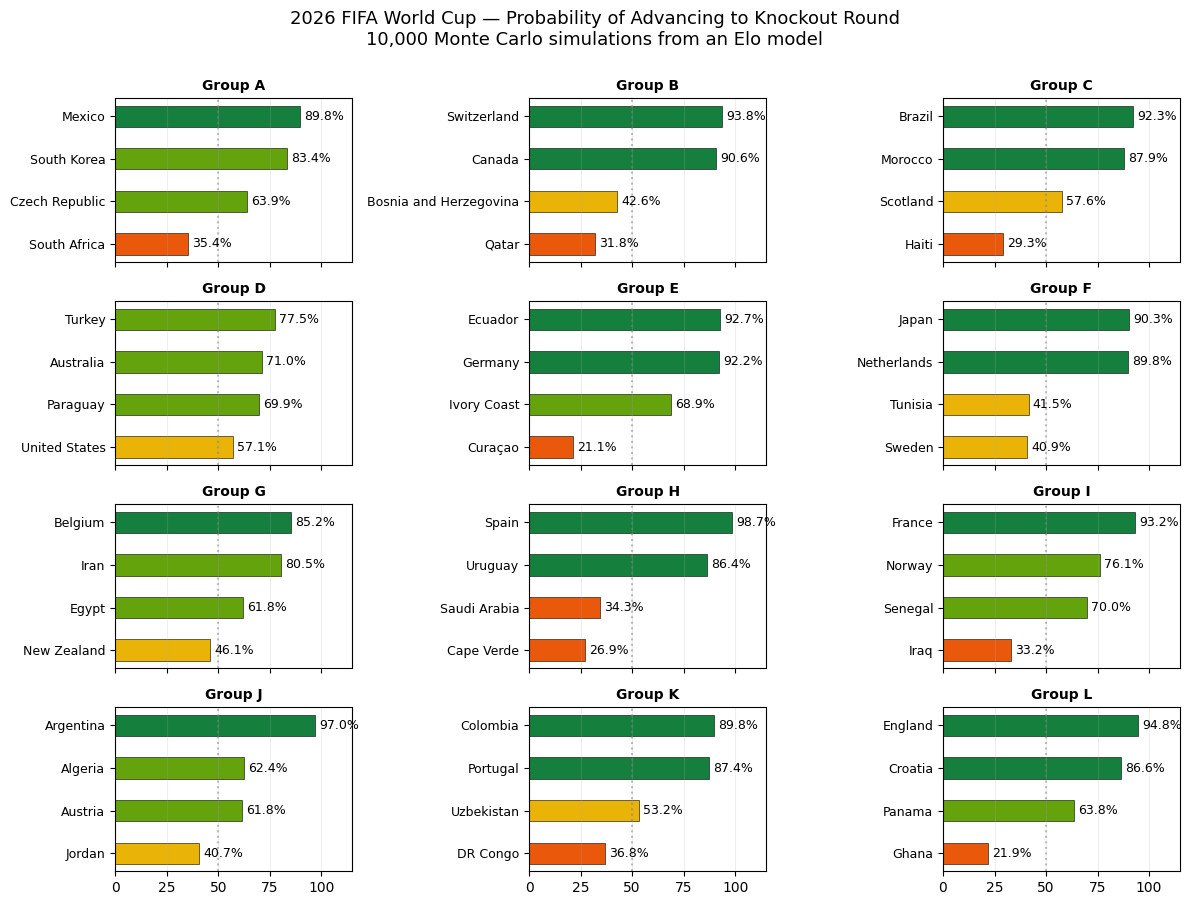

Saved group_advancement.png


In [ ]:
# Group advancement probabilities — 4x3 grid of mini panels.
# One small chart per group, so it's easy to compare teams within a
# group and compare groups against each other at a glance.

fig, axes = plt.subplots(4, 3, figsize=(12, 9), sharex=True)
axes = axes.flatten()  # turn the 4x3 grid into a flat list for easy iteration

# Color buckets — higher advance probability = greener.
# def color_for(p):
#     if p >= 0.85: return '#1a9850'   # dark green: very likely to advance
#     if p >= 0.60: return '#91cf60'   # light green: probably advances
#     if p >= 0.40: return '#fee08b'   # yellow: coin flip
#     if p >= 0.20: return '#fc8d59'   # orange: probably out
#     return '#d73027'                  # red: very unlikely
def color_for(p):
    if p >= 0.85: return '#15803d'   # deep green: very likely to advance
    if p >= 0.60: return '#65a30d'   # rich green: probably advances
    if p >= 0.40: return '#eab308'   # gold: coin flip
    if p >= 0.20: return '#ea580c'   # strong orange: probably out
    return '#b91c1c'                  # deep red: very unlikely

# Draw one panel per group
for ax, (group, teams) in zip(axes, GROUPS.items()):
    # Sort within group: weakest at bottom, strongest at top
    g_df = sim_df[sim_df['group'] == group].sort_values('p_advance', ascending=True)
    colors = [color_for(p) for p in g_df['p_advance']]

    # Main bars
    ax.barh(g_df['team'], g_df['p_advance'] * 100, height=0.50, 
            color=colors, edgecolor='black', linewidth=0.4)

    # Numeric label at the end of each bar (1 decimal place)
    for i, p in enumerate(g_df['p_advance']):
        ax.text(p * 100 + 2, i, f'{p*100:.1f}%', va='center', fontsize=9)

    # Panel formatting
    ax.set_title(f'Group {group}', fontsize=10, fontweight='bold')
    ax.set_xlim(0, 115)                  # leave room for the % label
    ax.axvline(50, color='gray', linestyle=':', alpha=0.5)  # 50% reference
    ax.grid(axis='x', alpha=0.2)
    ax.tick_params(axis='y', labelsize=9)

# Shared title across the whole figure

fig.suptitle('2026 FIFA World Cup — Probability of Advancing to Knockout Round\n'
             f'{N_SIMS:,} Monte Carlo simulations from an Elo model',
             fontsize=13, y=1.00, fontweight='normal')

plt.tight_layout()
plt.savefig('../data/processed/group_advancement.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved group_advancement.png")











## 6. Load the knockout bracket / K.O.-Bracket laden

Load `src/bracket.py`, which encodes FIFA's official Round of 32 pairings and the
**495-combination Annex C table** that determines where each third-placer goes
based on which 8 groups they came from. Sanity checks confirm 16 R32 matches,
15 later pairings, and exactly 495 placement combinations.

---

Laden von `src/bracket.py`, das FIFAs offizielle Round-of-32-Paarungen und die
**495-Kombinationen-Tabelle aus Anhang C** kodiert, die festlegt, wohin jeder
Gruppendritte abhängig von den 8 Herkunftsgruppen geht. Plausibilitätsprüfungen
bestätigen 16 R32-Spiele, 15 spätere Paarungen und genau 495 Platzierungskombinationen.

In [25]:
# Reload the bracket module (in case you re-saved it during the session)
import importlib
import src.bracket
importlib.reload(src.bracket)
from src.bracket import (
    R32_MATCHES,
    LATER_ROUNDS,
    THIRD_PLACE_SLOTS,
    SLOT_TO_MATCH,
    THIRD_PLACEMENTS,
)

# Sanity checks
print(f"R32 matches defined: {len(R32_MATCHES)} (expected 16)")
print(f"Later round pairings: {len(LATER_ROUNDS)} (expected 15)")
print(f"Third-place placement combinations: {len(THIRD_PLACEMENTS)} (expected 495)")

# Verify combination #1: if E,F,G,H,I,J,K,L advance as third-placers
combo1 = tuple(sorted(['E', 'F', 'G', 'H', 'I', 'J', 'K', 'L']))
print(f"\nExample placement (3rd from E,F,G,H,I,J,K,L):")
for slot, third_group in THIRD_PLACEMENTS[combo1].items():
    match_num = SLOT_TO_MATCH[slot]
    print(f"  Match {match_num}: Group {slot} winner vs Group {third_group} third-placer")

R32 matches defined: 16 (expected 16)
Later round pairings: 15 (expected 15)
Third-place placement combinations: 495 (expected 495)

Example placement (3rd from E,F,G,H,I,J,K,L):
  Match 79: Group A winner vs Group E third-placer
  Match 85: Group B winner vs Group J third-placer
  Match 81: Group D winner vs Group I third-placer
  Match 74: Group E winner vs Group F third-placer
  Match 82: Group G winner vs Group H third-placer
  Match 77: Group I winner vs Group G third-placer
  Match 87: Group K winner vs Group L third-placer
  Match 80: Group L winner vs Group K third-placer


## 7. Full-tournament simulator / Vollständiger Turnier-Simulator

`simulate_full_tournament` plays a complete World Cup: group stage → Round of 32
→ Round of 16 → Quarter-finals → Semi-finals → Final. Knockout matches have no
draws (extra time + penalties simplified to a single Elo-weighted draw). A test
run confirms it produces sensible results, strong teams reach the latter rounds.

---

`simulate_full_tournament` spielt eine vollständige WM: Gruppenphase → Achtelfinale
mit 32 Mannschaften → 16er-Runde → Viertelfinale → Halbfinale → Finale. K.O.-Spiele
kennen kein Unentschieden (Verlängerung + Elfmeterschießen vereinfacht zu einem
einzelnen Elo-gewichteten Zug). Ein Testlauf bestätigt sinnvolle Ergebnisse,
starke Mannschaften erreichen die späteren Runden.

In [26]:
# Full tournament Monte Carlo: group stage + R32 + R16 + QF + SF + Final
# Each match's winner is sampled from Elo-derived probabilities.

# Round labels for tracking how far each team progressed
ROUND_FROM_MATCH = {}
for m in range(73, 89):
    ROUND_FROM_MATCH[m] = 'R32'
for m, _, _ in LATER_ROUNDS:
    if 89 <= m <= 96:
        ROUND_FROM_MATCH[m] = 'R16'
    elif 97 <= m <= 100:
        ROUND_FROM_MATCH[m] = 'QF'
    elif 101 <= m <= 102:
        ROUND_FROM_MATCH[m] = 'SF'
    elif m == 104:
        ROUND_FROM_MATCH[m] = 'Final'

# How far a team got = the LAST round they played in (won or lost in)
# Mapping: winning R32 -> reached R16, etc.
NEXT_ROUND = {'R32': 'R16', 'R16': 'QF', 'QF': 'SF', 'SF': 'Final', 'Final': 'Champion'}


def simulate_knockout_match(team_a, team_b, ratings, rng):
    """Knockout matches have no draws (extra time / penalties). Return winner."""
    p_a = expected_score(ratings[team_a], ratings[team_b])
    return team_a if rng.random() < p_a else team_b


def simulate_full_tournament(elo_dict, rng):
    """Run one full tournament. Return dict: team -> furthest round reached.
    Rounds: 'Group' (didn't advance), 'R32', 'R16', 'QF', 'SF', 'Final', 'Champion'.
    """
    # 1. Group stage
    group_winners, group_runners, group_thirds = {}, {}, {}
    third_with_stats = []  # for picking the best 8
    
    for group_letter, teams in GROUPS.items():
        ranked = simulate_group_with_stats(teams, elo_dict, rng)
        group_winners[group_letter] = ranked[0][0]
        group_runners[group_letter] = ranked[1][0]
        group_thirds[group_letter] = ranked[2][0]
        third_with_stats.append((group_letter, ranked[2][0], ranked[2][1], ranked[2][2]))
    
    # 2. Pick best 8 third-place teams (FIFA rule: pts, then GD, then random)
    third_with_stats.sort(key=lambda x: (x[2], x[3], rng.random()), reverse=True)
    advancing_thirds = third_with_stats[:8]
    advancing_third_groups = sorted([t[0] for t in advancing_thirds])
    # Map group_letter -> team name (only for advancing thirds)
    third_team_by_group = {t[0]: t[1] for t in advancing_thirds}
    
    # Initialize progress: everyone gets at least 'Group'
    progress = {team: 'Group' for team in ALL_TEAMS}
    
    # Eliminated 3rd-placers and all 4th-placers stay at 'Group'
    
    # 3. Determine R32 matchups using the 495-combination table
    placement = THIRD_PLACEMENTS[tuple(advancing_third_groups)]
    
    # match_winner[match_num] -> team that wins it
    match_winner = {}
    
    # Solve R32 matches
    # Some R32 matches are "Winner X vs 3rd from slot X" (use placement)
    # Others are runner-up vs runner-up
    
    # R32 match resolution — encode it directly from the FIFA spec
    def resolve_r32():
        # Match 73: R-A vs R-B
        match_winner[73] = simulate_knockout_match(group_runners['A'], group_runners['B'], elo_dict, rng)
        # Match 74: W-E vs 3rd at slot E
        third_for_E = third_team_by_group[placement['E']]
        match_winner[74] = simulate_knockout_match(group_winners['E'], third_for_E, elo_dict, rng)
        # Match 75: W-F vs R-C
        match_winner[75] = simulate_knockout_match(group_winners['F'], group_runners['C'], elo_dict, rng)
        # Match 76: W-C vs R-F
        match_winner[76] = simulate_knockout_match(group_winners['C'], group_runners['F'], elo_dict, rng)
        # Match 77: W-I vs 3rd at slot I
        third_for_I = third_team_by_group[placement['I']]
        match_winner[77] = simulate_knockout_match(group_winners['I'], third_for_I, elo_dict, rng)
        # Match 78: R-E vs R-I
        match_winner[78] = simulate_knockout_match(group_runners['E'], group_runners['I'], elo_dict, rng)
        # Match 79: W-A vs 3rd at slot A
        third_for_A = third_team_by_group[placement['A']]
        match_winner[79] = simulate_knockout_match(group_winners['A'], third_for_A, elo_dict, rng)
        # Match 80: W-L vs 3rd at slot L
        third_for_L = third_team_by_group[placement['L']]
        match_winner[80] = simulate_knockout_match(group_winners['L'], third_for_L, elo_dict, rng)
        # Match 81: W-D vs 3rd at slot D
        third_for_D = third_team_by_group[placement['D']]
        match_winner[81] = simulate_knockout_match(group_winners['D'], third_for_D, elo_dict, rng)
        # Match 82: W-G vs 3rd at slot G
        third_for_G = third_team_by_group[placement['G']]
        match_winner[82] = simulate_knockout_match(group_winners['G'], third_for_G, elo_dict, rng)
        # Match 83: R-K vs R-L
        match_winner[83] = simulate_knockout_match(group_runners['K'], group_runners['L'], elo_dict, rng)
        # Match 84: W-H vs R-J
        match_winner[84] = simulate_knockout_match(group_winners['H'], group_runners['J'], elo_dict, rng)
        # Match 85: W-B vs 3rd at slot B
        third_for_B = third_team_by_group[placement['B']]
        match_winner[85] = simulate_knockout_match(group_winners['B'], third_for_B, elo_dict, rng)
        # Match 86: W-J vs R-H
        match_winner[86] = simulate_knockout_match(group_winners['J'], group_runners['H'], elo_dict, rng)
        # Match 87: W-K vs 3rd at slot K
        third_for_K = third_team_by_group[placement['K']]
        match_winner[87] = simulate_knockout_match(group_winners['K'], third_for_K, elo_dict, rng)
        # Match 88: R-D vs R-G
        match_winner[88] = simulate_knockout_match(group_runners['D'], group_runners['G'], elo_dict, rng)
    
    # Mark everyone who made R32
    # Group winners + runners + advancing thirds all played in R32
    r32_teams = list(group_winners.values()) + list(group_runners.values()) + list(third_team_by_group.values())
    for team in r32_teams:
        progress[team] = 'R32'
    
    resolve_r32()
    
    # Process later rounds (R16, QF, SF, Final) using LATER_ROUNDS list
    for match_num, m1, m2 in LATER_ROUNDS:
        team_a = match_winner[m1]
        team_b = match_winner[m2]
        # Both teams reached this round (winning their previous match)
        round_name = ROUND_FROM_MATCH[match_num]
        progress[team_a] = round_name
        progress[team_b] = round_name
        # Simulate
        match_winner[match_num] = simulate_knockout_match(team_a, team_b, elo_dict, rng)
    
    # Champion = winner of final (match 104)
    progress[match_winner[104]] = 'Champion'
    
    return progress


# Test one tournament
test_rng = np.random.default_rng(42)
one_result = simulate_full_tournament(elo, test_rng)
print("Sample tournament result — top finishers:")
ROUND_ORDER = ['Group', 'R32', 'R16', 'QF', 'SF', 'Final', 'Champion']
for round_name in reversed(ROUND_ORDER[1:]):  # skip 'Group'
    teams_here = [t for t, r in one_result.items() if r == round_name]
    if teams_here:
        print(f"  {round_name}: {', '.join(teams_here)}")

Sample tournament result — top finishers:
  Champion: Spain
  Final: Argentina
  SF: Brazil, Japan
  QF: Belgium, Norway, Portugal, Panama
  R16: Bosnia and Herzegovina, Switzerland, Ivory Coast, Ecuador, Iran, Iraq, Austria, Colombia
  R32: Mexico, South Africa, Czech Republic, Canada, Scotland, United States, Turkey, Germany, Netherlands, New Zealand, Saudi Arabia, Uruguay, Jordan, DR Congo, England, Croatia


## 8. Run 10,000 full-tournament simulations / 10.000 vollständige Turnier-Simulationen

The headline output: per-team probability of reaching each round, from "made R32"
through "won the Cup". Spain (24.4%) and Argentina (20.5%) emerge as joint
favourites, together accounting for nearly half of all simulated championships.

---

Die zentrale Ausgabe: Wahrscheinlichkeit pro Mannschaft, jede Runde zu erreichen,
von "ins Achtelfinale gekommen" bis "die WM gewonnen". Spanien (24.4%) und
Argentinien (20.5%) gehen als gemeinsame Favoriten hervor und vereinen zusammen
fast die Hälfte aller simulierten Meisterschaften.

In [27]:
# Run 10,000 full tournaments and aggregate per-team round progression
N_SIMS_FULL = 10_000
rng = np.random.default_rng(42)

# Counter: team -> {round_name: count}
ROUND_LABELS = ['Group', 'R32', 'R16', 'QF', 'SF', 'Final', 'Champion']
results_full = {team: {r: 0 for r in ROUND_LABELS} for team in ALL_TEAMS}

for sim in range(N_SIMS_FULL):
    progress = simulate_full_tournament(elo, rng)
    for team, round_reached in progress.items():
        results_full[team][round_reached] += 1
    if sim % 2000 == 0:
        print(f"  sim {sim}/{N_SIMS_FULL}")

print(f"\nDone: {N_SIMS_FULL:,} tournaments simulated")

  sim 0/10000
  sim 2000/10000
  sim 4000/10000
  sim 6000/10000
  sim 8000/10000

Done: 10,000 tournaments simulated


## 9. Aggregate results and visualise / Ergebnisse aggregieren und visualisieren

Turn 10,000 tournaments into per-team probabilities for each round (R32 through
Champion), print the top 20 contenders as a table, then plot the flagship chart:
top 16 teams as a horizontal bar broken down by how far they typically progress.

Reading the colour stack tells you the team's journey at a glance, light grey
= lost early, green = lifted the trophy. This image becomes a centrepiece of the
README and the live dashboard.

---

Umwandlung von 10.000 Turnieren in Wahrscheinlichkeiten pro Mannschaft für jede
Runde (Achtelfinale bis Meisterschaft), Ausgabe der 20 besten Anwärter als Tabelle,
anschließend Erstellung des Aushängeschild-Diagramms: die Top 16 als horizontaler
Balken, aufgeschlüsselt nach dem typischen Werdegang.

Das Lesen des Farbstapels zeigt auf einen Blick den Werdegang der Mannschaft,
hellgrau = früh ausgeschieden, grün = den Pokal in die Höhe gestemmt. Dieses
Bild wird zum Herzstück der README und des Live-Dashboards.

In [28]:
# Aggregate into a clean dataframe
# For each team: probability of reaching each round AT LEAST
rows = []
for team, counts in results_full.items():
    # Cumulative: P(reach R16) = made R16 + QF + SF + Final + Champion
    # Note: 'Champion' means they won the final, so they "reached" all rounds
    cum_r32 = sum(counts[r] for r in ['R32','R16','QF','SF','Final','Champion'])
    cum_r16 = sum(counts[r] for r in ['R16','QF','SF','Final','Champion'])
    cum_qf  = sum(counts[r] for r in ['QF','SF','Final','Champion'])
    cum_sf  = sum(counts[r] for r in ['SF','Final','Champion'])
    cum_fin = sum(counts[r] for r in ['Final','Champion'])
    cum_win = counts['Champion']
    rows.append({
        'team': team,
        'group': team_to_group[team],
        'elo': int(elo[team]),
        'p_r32':     cum_r32 / N_SIMS_FULL,
        'p_r16':     cum_r16 / N_SIMS_FULL,
        'p_qf':      cum_qf  / N_SIMS_FULL,
        'p_sf':      cum_sf  / N_SIMS_FULL,
        'p_final':   cum_fin / N_SIMS_FULL,
        'p_champ':   cum_win / N_SIMS_FULL,
    })

full_df = pd.DataFrame(rows).sort_values('p_champ', ascending=False).reset_index(drop=True)
full_df.index += 1  # rank from 1

# Save for the dashboard / README
full_df.to_csv("../data/processed/full_tournament_simulation.csv", index=False)

# Print top 20 contenders
print("="*72)
print("2026 WORLD CUP — TOURNAMENT PROGRESSION PROBABILITIES")
print(f"Based on {N_SIMS_FULL:,} Monte Carlo simulations of the full bracket")
print("="*72)
display_df = full_df.head(20).copy()
for col in ['p_r32', 'p_r16', 'p_qf', 'p_sf', 'p_final', 'p_champ']:
    display_df[col] = (display_df[col] * 100).map('{:.1f}%'.format)
print(display_df[['team','group','elo','p_r32','p_r16','p_qf','p_sf','p_final','p_champ']].to_string())

print(f"\nSaved full_tournament_simulation.csv ({len(full_df)} teams)")

2026 WORLD CUP — TOURNAMENT PROGRESSION PROBABILITIES
Based on 10,000 Monte Carlo simulations of the full bracket
           team group   elo  p_r32  p_r16   p_qf   p_sf p_final p_champ
1         Spain     H  2171  98.6%  76.8%  59.5%  48.9%   36.2%   24.4%
2     Argentina     J  2149  97.0%  70.0%  56.7%  43.6%   31.9%   20.5%
3        France     I  2081  93.1%  70.7%  48.6%  32.0%   17.8%    9.9%
4       England     L  2046  94.9%  64.5%  41.3%  25.1%   12.7%    6.5%
5      Colombia     K  2027  90.3%  60.2%  35.9%  18.9%   10.4%    4.8%
6        Brazil     C  2031  92.2%  58.7%  36.4%  20.9%    9.5%    4.7%
7      Portugal     K  1992  87.2%  53.7%  29.5%  14.8%    7.3%    3.2%
8         Japan     F  1985  90.3%  48.3%  29.4%  15.5%    6.7%    2.9%
9       Ecuador     E  1990  92.6%  57.8%  30.5%  16.8%    7.3%    2.9%
10      Morocco     C  1974  87.5%  49.1%  27.7%  14.0%    5.8%    2.4%
11      Germany     E  1977  91.7%  55.4%  27.7%  14.2%    6.4%    2.4%
12  Netherlands     F 

## 10. Visualisation — championship probabilities / Visualisierung — Meisterschaftswahrscheinlichkeiten

The flagship chart: top 16 contenders, with each team's bar broken down by how
far they typically progress. Reading the colour stack tells you the team's
journey at a glance, light grey = lost early, green = lifted the trophy.

This image becomes a centrepiece of the README and the live dashboard.

---

Das Aushängeschild-Diagramm: die Top-16-Anwärter, wobei der Balken jeder Mannschaft
danach aufgeschlüsselt ist, wie weit sie typischerweise kommt. Das Lesen des
Farbstapels zeigt auf einen Blick den Werdegang der Mannschaft, hellgrau =
früh ausgeschieden, grün = den Pokal in die Höhe gestemmt.

Dieses Bild wird zum Herzstück der README und des Live-Dashboards.

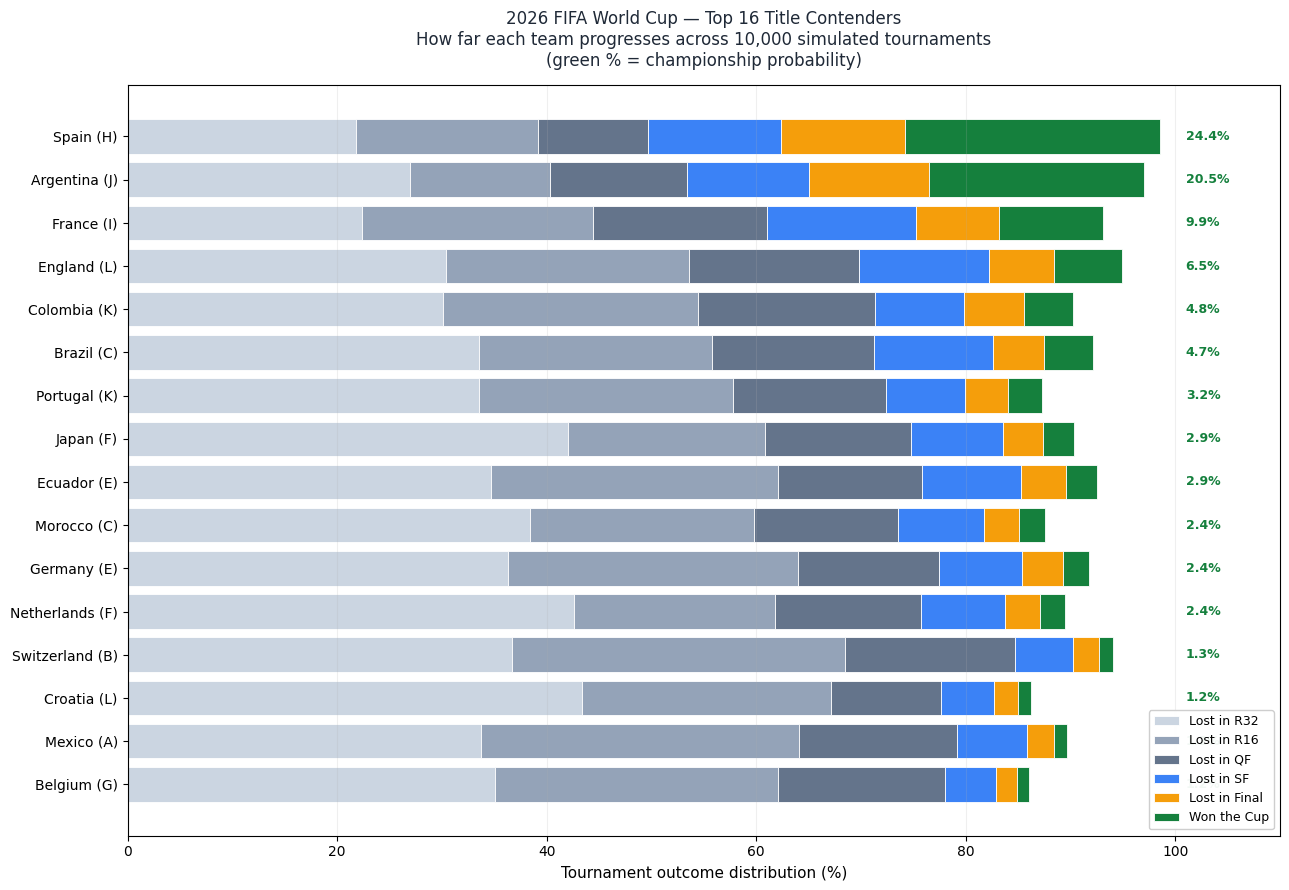

Saved championship_probabilities.png


In [29]:
import matplotlib.patches as mpatches

# Show top 16 teams as a horizontal bar chart with progression breakdown
top16 = full_df.head(16).copy().reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 9))
y_positions = np.arange(len(top16))

# Stacked bars showing progression: each segment is the marginal probability
# of being eliminated AT THAT round.
# P(elim in R32) = 1 - p_r16 considering they made R32 first... 
# Cleaner: show cumulative probabilities as nested bars.
# We plot from outermost (made R32) inward, each bar painted over the previous.

colors = {
    'r32':   '#cbd5e1',  # light gray: made R32 but didn't advance
    'r16':   '#94a3b8',
    'qf':    '#64748b',
    'sf':    '#3b82f6',  # blue: semifinal
    'final': '#f59e0b',  # amber: reached final
    'champ': '#15803d',  # green: won it
}
labels_map = {
    'r32':   'Lost in R32',
    'r16':   'Lost in R16',
    'qf':    'Lost in QF',
    'sf':    'Lost in SF',
    'final': 'Lost in Final',
    'champ': 'Won the Cup',
}

# Marginal probabilities (don't double-count)
top16['p_lost_r32']   = top16['p_r32']   - top16['p_r16']
top16['p_lost_r16']   = top16['p_r16']   - top16['p_qf']
top16['p_lost_qf']    = top16['p_qf']    - top16['p_sf']
top16['p_lost_sf']    = top16['p_sf']    - top16['p_final']
top16['p_lost_final'] = top16['p_final'] - top16['p_champ']
top16['p_won']        = top16['p_champ']

stack_cols   = ['p_lost_r32', 'p_lost_r16', 'p_lost_qf', 'p_lost_sf', 'p_lost_final', 'p_won']
stack_colors = [colors['r32'], colors['r16'], colors['qf'], colors['sf'], colors['final'], colors['champ']]
stack_labels = [labels_map[k] for k in ['r32', 'r16', 'qf', 'sf', 'final', 'champ']]

left = np.zeros(len(top16))
for col, color, label in zip(stack_cols, stack_colors, stack_labels):
    values = top16[col].values * 100
    ax.barh(y_positions, values, left=left, color=color,
            edgecolor='white', linewidth=0.6, label=label)
    left += values

# Champion % at end of each bar
for i, p in enumerate(top16['p_champ']):
    if p > 0.005:
        ax.text(101, i, f'{p*100:.1f}%', va='center',
                fontsize=9, fontweight='bold', color='#15803d')

ax.set_yticks(y_positions)
ax.set_yticklabels([f"{r['team']} ({r['group']})" for _, r in top16.iterrows()], fontsize=10)
ax.invert_yaxis()  # best team at top
ax.set_xlabel('Tournament outcome distribution (%)', fontsize=11)
ax.set_xlim(0, 110)
ax.set_title('2026 FIFA World Cup — Top 16 Title Contenders\n'
             f'How far each team progresses across {N_SIMS_FULL:,} simulated tournaments\n'
             '(green % = championship probability)',
             fontsize=12, pad=14, color='#1f2937')
ax.legend(loc='lower right', framealpha=0.95, fontsize=9)
ax.grid(axis='x', alpha=0.2)

plt.tight_layout()
plt.savefig('../data/processed/championship_probabilities.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved championship_probabilities.png")